In [1]:
import pandas as pd

customers = pd.read_csv("data/customers.csv")
orders = pd.read_csv("data/orders.csv")
support_tickets = pd.read_csv("data/support_tickets.csv")
web_event_snapshot = pd.read_csv("data/rfm_modeling_snapshot.csv")
churn_labels = pd.read_csv("data/churn_labels.csv")
intervention_history = pd.read_csv("data/intervention_history.csv")

datasets ={
    "customers" : customers,
    "orders":orders,
    "support_tickets":support_tickets,
    "web_event_snapshot" : web_event_snapshot,
    "churn_labels" : churn_labels,
    "intervention_history":intervention_history

}

print( "===DATA AUDIT FOR THE CHURN ====")
for name ,df in datasets.items():
    print(f"---Dataset :{name.upper()}---")
    print(f"shape(rows,column) :{df.shape}")
    print(f"Total Duplictate Rows :{df.duplicated().sum()}")


    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({"Missing Values": missing, "Percentage (%)": missing_pct})
    print(missing_df[missing_df["Missing Values"] > 0])
    print("\n" + "="*40 + "\n")


===DATA AUDIT FOR THE CHURN ====
---Dataset :CUSTOMERS---
shape(rows,column) :(2400, 9)
Total Duplictate Rows :0
              Missing Values  Percentage (%)
loyalty_tier            1386       57.750000
skin_type                401       16.708333


---Dataset :ORDERS---
shape(rows,column) :(10009, 10)
Total Duplictate Rows :0
        Missing Values  Percentage (%)
rating              80        0.799281


---Dataset :SUPPORT_TICKETS---
shape(rows,column) :(1921, 8)
Total Duplictate Rows :0
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


---Dataset :WEB_EVENT_SNAPSHOT---
shape(rows,column) :(2400, 29)
Total Duplictate Rows :0
              Missing Values  Percentage (%)
loyalty_tier            1386           57.75


---Dataset :CHURN_LABELS---
shape(rows,column) :(2400, 4)
Total Duplictate Rows :0
Empty DataFrame
Columns: [Missing Values, Percentage (%)]
Index: []


---Dataset :INTERVENTION_HISTORY---
shape(rows,column) :(2400, 5)
Total Duplictate Rows :0
Empty Dat

In [2]:
# Check if all customer IDs in peripheral tables exist in the primary customers table
master_cust_ids = set(customers['customer_id'])
for name ,df in datasets.items():
    if name != 'customers' and 'customer_id' in df.columns:
        df_cust_ids= set(df['customer_id'].dropna())
        orphans = df_cust_ids -master_cust_ids
        print(f"Orphaned customers in {name}: {len(orphans)} IDs do not match primary records ")

Orphaned customers in orders: 0 IDs do not match primary records 
Orphaned customers in support_tickets: 0 IDs do not match primary records 
Orphaned customers in web_event_snapshot: 0 IDs do not match primary records 
Orphaned customers in churn_labels: 0 IDs do not match primary records 
Orphaned customers in intervention_history: 0 IDs do not match primary records 


In [9]:
print(churn_labels.columns.tolist())


['customer_id', 'snapshot_date', 'churn_next_60d', 'split']


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_labels['churn_next_60d'] = churn_labels['churn_next_60d'].astype(int)


df_master = customers.merge(churn_labels, on='customer_id', how='left')

tickets_counts = support_tickets.groupby('customer_id').size().reset_index(name='ticket_count')
df_master = df_master.merge(tickets_counts, on='customer_id', how='left').fillna({'ticket_count': 0})

print("Master Dataframe configure for the visiualisation. Column list :")
print(df_master.columns.tolist())

Master Dataframe configure for the visiualisation. Column list :
['customer_id', 'signup_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'skin_type', 'marketing_consent', 'snapshot_date', 'churn_next_60d', 'split', 'ticket_count']


/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_1980/3745938015.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_master,x='city_tier', y='churn_next_60d', ci=None ,palette='viridis')
/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_1980/3745938015.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_master,x='city_tier', y='churn_next_60d', ci=None ,palette='viridis')
/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_1980/3745938015.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_master , x='age_group' , y='churn_next_60d', ci=None ,palette='magma' )
/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_1980/3745938015.py:9: FutureWarning: 

Passing `pal

Text(0, 0.5, 'Proportion Churned')

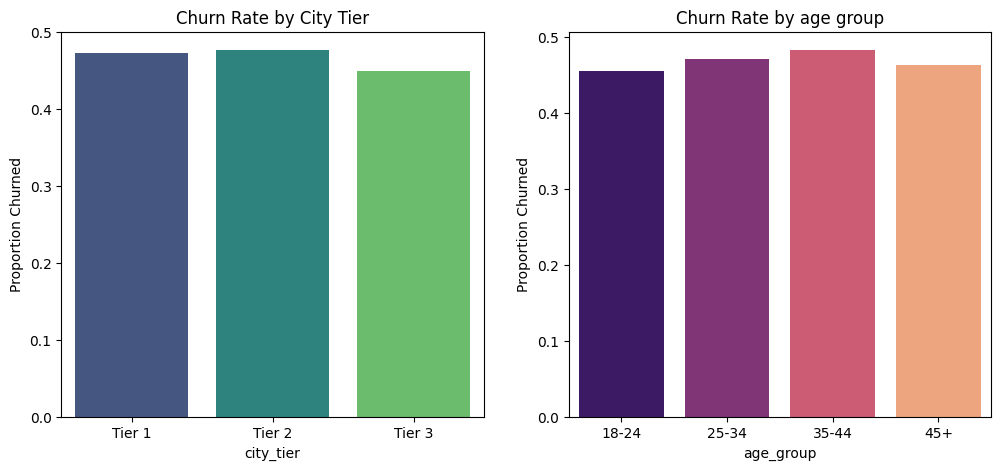

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.barplot(data=df_master,x='city_tier', y='churn_next_60d', ci=None ,palette='viridis')
plt.title('Churn Rate by City Tier')
plt.ylabel('Proportion Churned')

plt.subplot(1,2,2)
sns.barplot(data=df_master , x='age_group' , y='churn_next_60d', ci=None ,palette='magma' )
plt.title('Churn Rate by age group')
plt.ylabel('Proportion Churned')


/var/folders/6y/13cl8rqn7p3_hl58cdsfkl6h0000gn/T/ipykernel_1980/1911215229.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_master, x='ticket_count', y='churn_next_60d', ci=None, color='salmon')


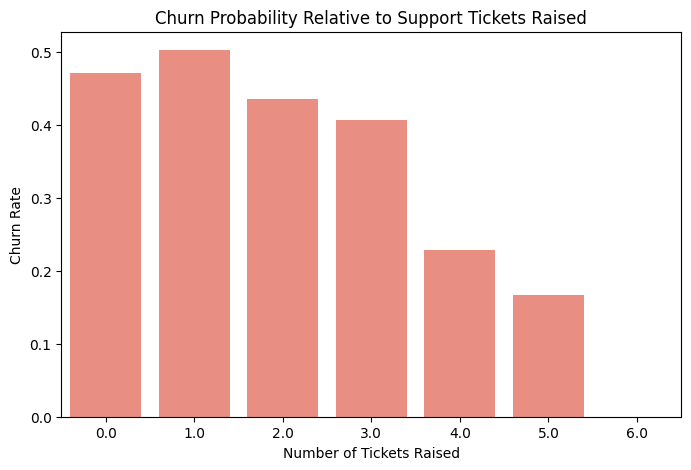

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_master, x='ticket_count', y='churn_next_60d', ci=None, color='salmon')
plt.title('Churn Probability Relative to Support Tickets Raised')
plt.xlabel('Number of Tickets Raised')
plt.ylabel('Churn Rate')
plt.show()